In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, classification_report,
                            confusion_matrix, precision_recall_curve)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [29]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [30]:
# ==============================================
# 1. Data Loading and Initial Preparation
# ==============================================
data = pd.read_csv('wedowind.csv')

data.drop('Unnamed: 0', axis=1, inplace=True)

# Convert timestamp
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Create temporal features
data['hour'] = data['timestamp'].dt.hour
data['month'] = data['timestamp'].dt.month
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['day_of_year'] = data['timestamp'].dt.dayofyear

# Create seasons
seasons_dict = {1: 'Winter', 2: 'Winter', 3: 'Spring',
                4: 'Spring', 5: 'Spring', 6: 'Summer',
                7: 'Summer', 8: 'Summer', 9: 'Autumn',
                10: 'Autumn', 11: 'Autumn', 12: 'Winter'}
data['seasons'] = data['month'].map(seasons_dict)

# Create failure indicator
data['failure'] = (data['errorcode'] != 0).astype(int)


Data Statistics:
          plant_name                      timestamp     wind_speed  \
count  521729.000000                         521729  521729.000000   
mean      114.803204  2021-07-12 04:43:15.370393600       0.623417   
min       109.000000            2020-06-30 22:00:00       0.000007   
25%       114.000000            2021-01-04 21:20:00       0.453608   
50%       115.000000            2021-07-12 00:00:00       0.623545   
75%       116.000000            2022-01-15 06:30:00       0.807051   
max       120.000000            2022-08-01 00:00:00       1.895970   
std         3.547718                            NaN       0.245780   

       turbulence_intensity  nacelle_direction    rotor_speed  \
count         521729.000000      521729.000000  521729.000000   
mean               0.140167         198.947115       0.748144   
min                0.000000           0.000000       0.000000   
25%                0.085649         181.962392       0.580362   
50%                0.11158

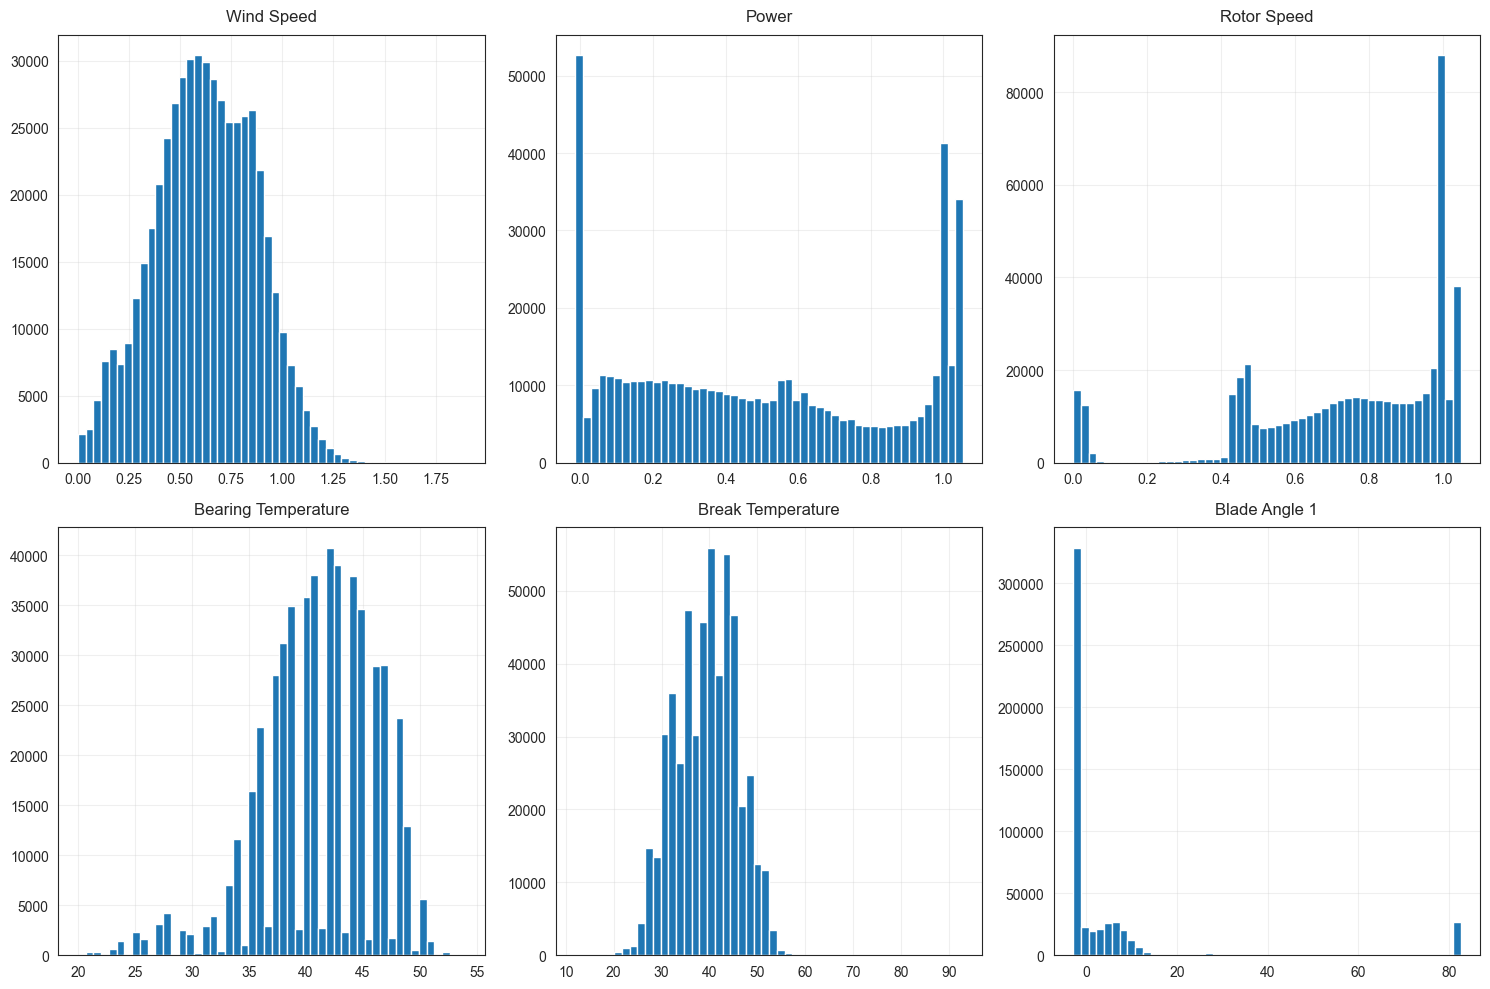

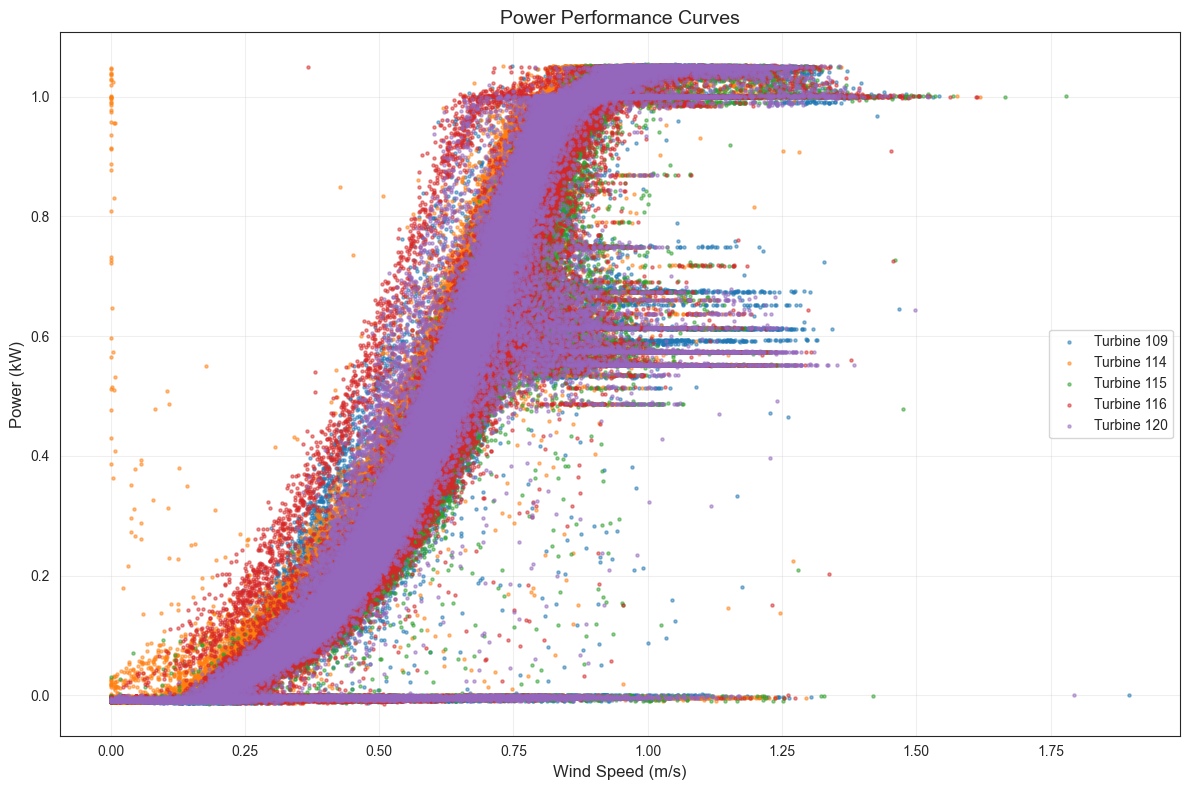

C:\Users\usuario\AppData\Local\Temp\ipykernel_19724\464802504.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='month', y='power', palette='Blues_d', ax=ax1)
C:\Users\usuario\AppData\Local\Temp\ipykernel_19724\464802504.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='month', y='wind_speed', palette='Greens_d', ax=ax2)


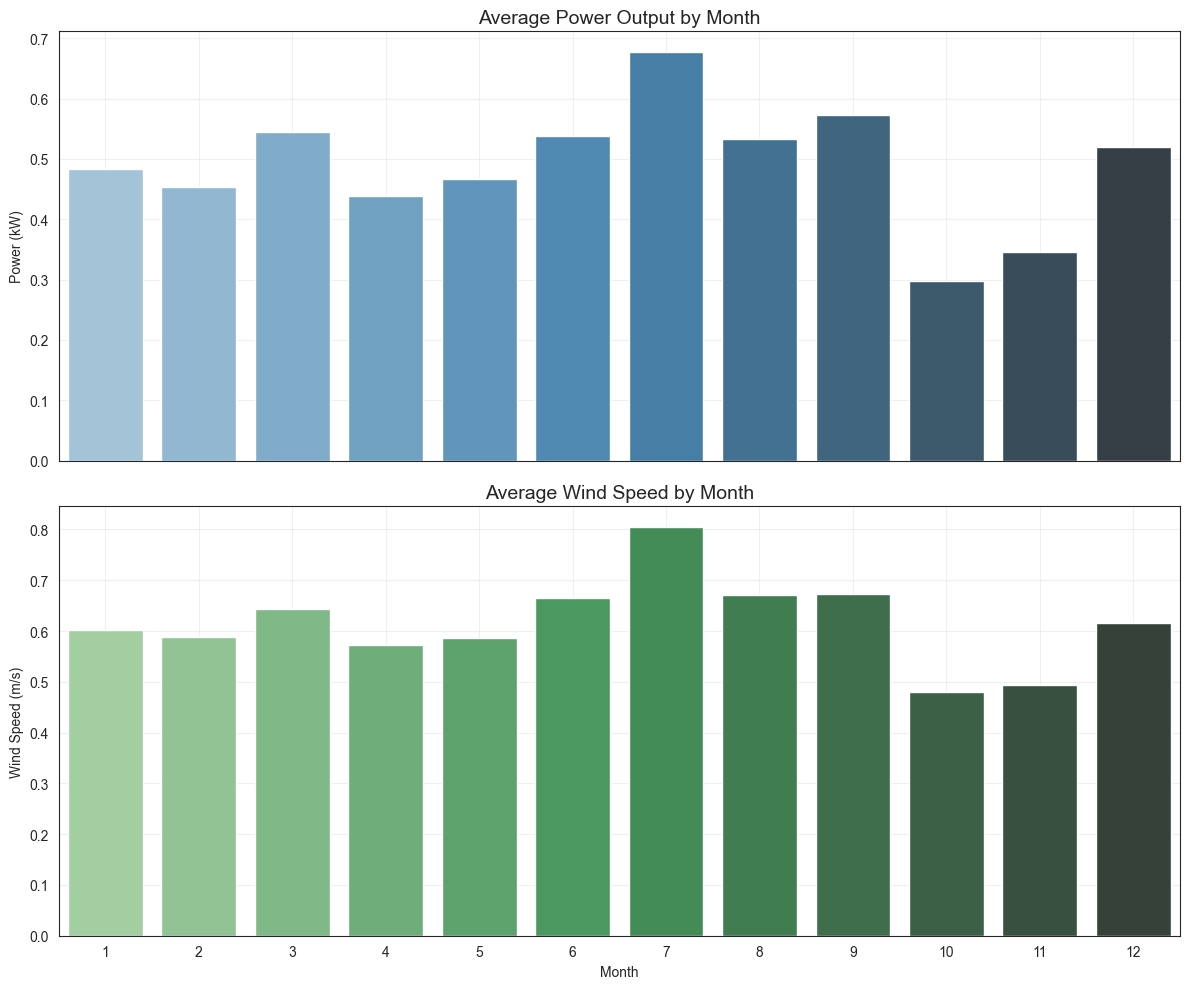

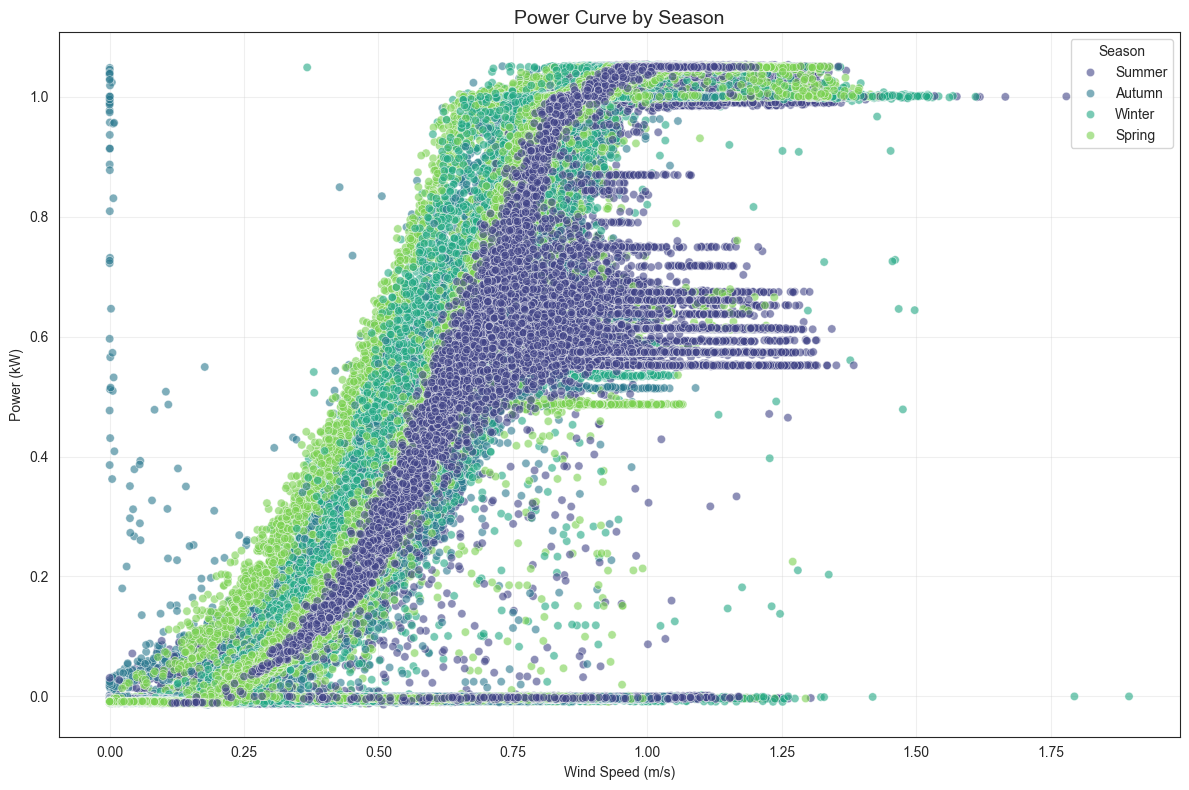

In [32]:
# ==============================================
# 2. Exploratory Data Analysis
# ==============================================

# Create figures directory
os.makedirs('figures', exist_ok=True)

# Set consistent style
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'grid.color': '#dddddd',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})
sns.set_style("white")

# Basic statistics
print("\nData Statistics:")
print(data.describe())
print("\nData Info:")
print(data.info())
print("\nMissing Values:")
print(data.isna().sum())

# Histograms of key features
features = ['wind_speed', 'power', 'rotor_speed', 'bearing_temperature',
           'break_temperature', 'blade_angle_1']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, feature in zip(axes.flatten(), features):
    data[feature].hist(bins=50, ax=ax, color='#1f77b4')
    ax.set_title(feature.replace("_", " ").title(), pad=10)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/feature_histograms.png', dpi=300, bbox_inches='tight')
plt.show()


# Power curves
plt.figure(figsize=(12, 8))
for turbine in data['plant_name'].unique():
    turbine_data = data[data['plant_name'] == turbine]
    plt.scatter(turbine_data['wind_speed'], turbine_data['power'],
               alpha=0.5, s=5, label=f'Turbine {turbine}')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.title('Power Performance Curves', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/all_turbines_power_curves.png', dpi=300)
plt.show()

# Monthly averages
monthly_avg = data.groupby('month').agg({
    'power': 'mean',
    'wind_speed': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
sns.barplot(data=monthly_avg, x='month', y='power', palette='Blues_d', ax=ax1)
ax1.set_title('Average Power Output by Month', fontsize=14)
ax1.set_ylabel('Power (kW)')
ax1.grid(True, alpha=0.3)

sns.barplot(data=monthly_avg, x='month', y='wind_speed', palette='Greens_d', ax=ax2)
ax2.set_title('Average Wind Speed by Month', fontsize=14)
ax2.set_ylabel('Wind Speed (m/s)')
ax2.set_xlabel('Month')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/monthlypower.png', dpi=300, bbox_inches='tight')
plt.show()

# Seasonal scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='wind_speed', y='power',
               hue='seasons', palette='viridis', alpha=0.6)
plt.title('Power Curve by Season', fontsize=14)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.grid(True, alpha=0.3)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('figures/seasonalpower.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# ==============================================
# 3. Data Preprocessing
# ==============================================

# Handle missing values
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='median')
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

# Feature engineering
print("\nAdding engineered features...")
for col in ['wind_speed', 'power', 'generator_temperature']:
    data[f'{col}_rolling_avg_6h'] = data.groupby('plant_name')[col].transform(
        lambda x: x.rolling(6, min_periods=1).mean())
    data[f'{col}_rolling_std_6h'] = data.groupby('plant_name')[col].transform(
        lambda x: x.rolling(6, min_periods=1).std())

data['power_per_wind'] = data['power'] / (data['wind_speed'] + 0.001)
data['temp_power_ratio'] = data['generator_temperature'] / (data['power'] + 1)

# Create TTF feature
print("\nCreating Time-to-Failure feature...")
def create_ttf_feature(group):
    """Create Time-to-Failure feature"""
    group = group.sort_values('timestamp')
    group['ttf'] = 0.0

    for i in range(len(group)):
        current_time = group.iloc[i]['timestamp']
        future_failures = group[(group['timestamp'] > current_time) & (group['failure'] == 1)]

        if not future_failures.empty:
            next_failure_time = future_failures.iloc[0]['timestamp']
            ttf_hours = (next_failure_time - current_time).total_seconds() / 3600
            group.loc[group.index[i], 'ttf'] = ttf_hours
        else:
            group.loc[group.index[i], 'ttf'] = np.nan

    return group

data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)

# Filter data for prediction (last 15 hours before failure, non-failure points)
data_ttf = data_ttf.dropna(subset=['ttf'])
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]
data_ttf = data_ttf[data_ttf['failure'] == 0]

print(f"\nFinal dataset for modeling: {len(data_ttf)} records")
print(f"Time-to-Failure range: {data_ttf['ttf'].min():.1f} to {data_ttf['ttf'].max():.1f} hours")


Adding engineered features...

Creating Time-to-Failure feature...

Final dataset for modeling: 73468 records
Time-to-Failure range: 0.2 to 15.0 hours


C:\Users\usuario\AppData\Local\Temp\ipykernel_19724\1303124075.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)



4. Running Approach A: Unsupervised Clustering + PCA + Supervised
Columns being used for clustering:
wind_speed                              float64
turbulence_intensity                    float64
nacelle_direction                       float64
rotor_speed                             float64
generator_speed                         float64
blade_angle_1                           float64
blade_angle_2                           float64
blade_angle_3                           float64
power                                   float64
cosphi                                  float64
temp_environment                        float64
generator_temperature                   float64
break_temperature                       float64
temp_hydraulic_oil                      float64
bearing_temperature                     float64
hydraulic_pressure                      float64
gear_pressure                           float64
wind_direction                          float64
wind_speed_reference              

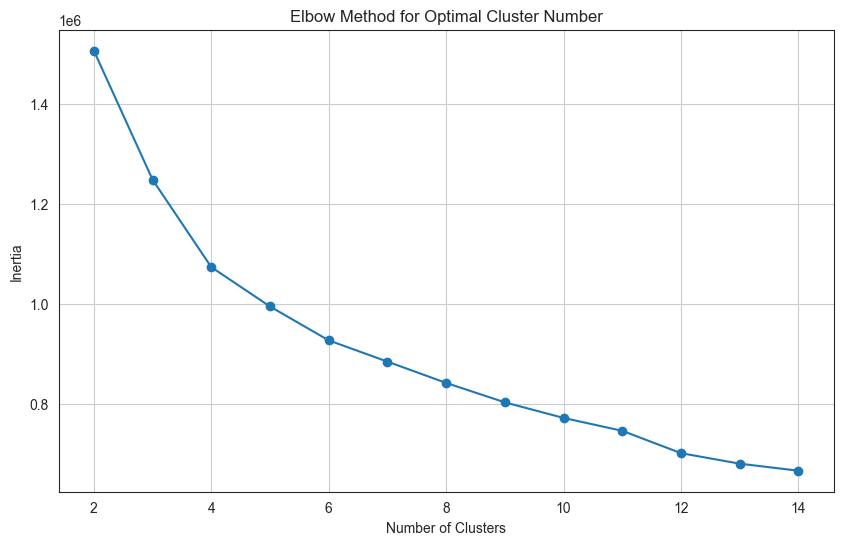


Reduced to 12 principal components
Explained variance ratio: 0.96


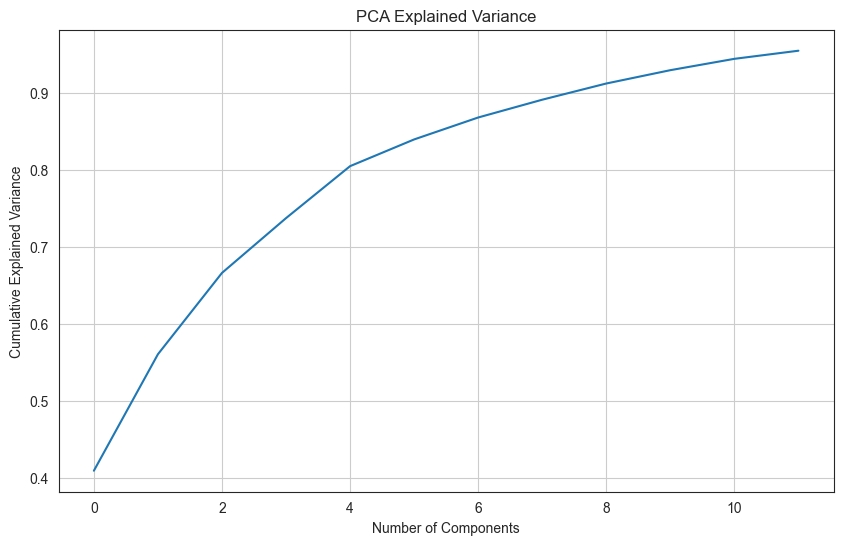

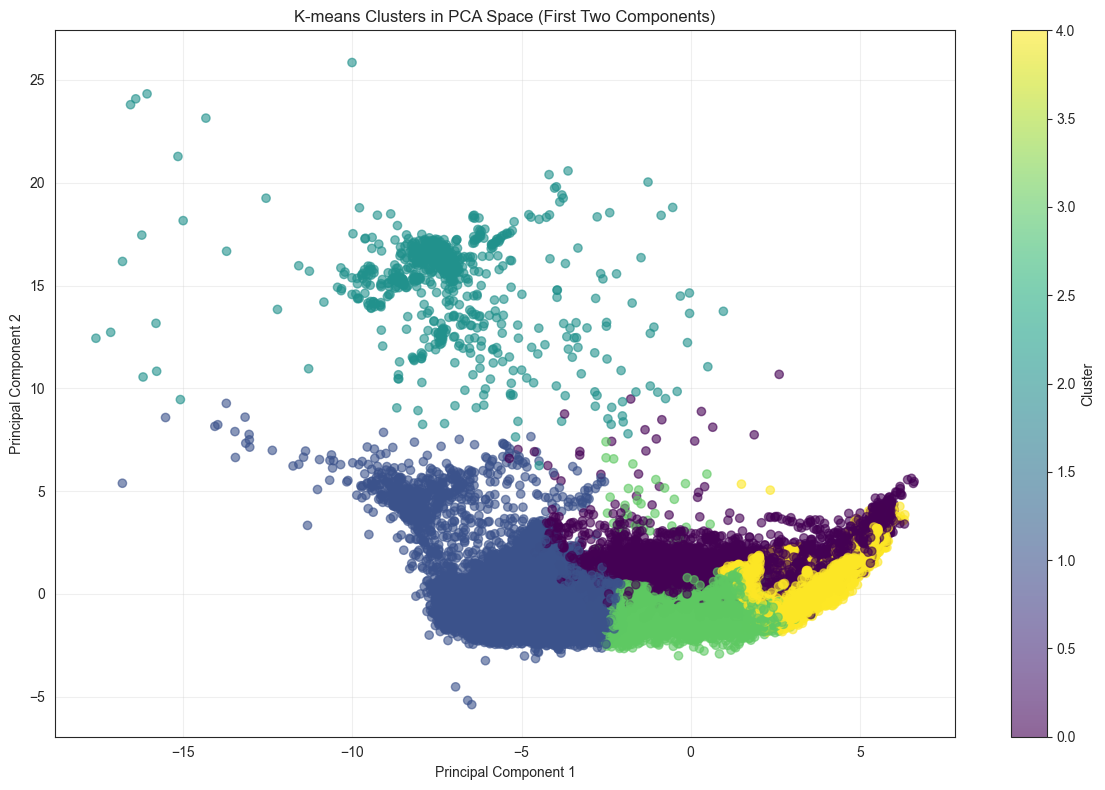


Cluster distribution:
cluster
3    27026
4    21006
1    18094
0     6461
2      881
Name: count, dtype: int64


In [37]:
# ==============================================
# 4. Modeling Approaches
# ==============================================

# ==============================================
# 4. Approach A: Unsupervised Clustering + PCA + Supervised
# ==============================================

print("\n4. Running Approach A: Unsupervised Clustering + PCA + Supervised")

# Prepare features for clustering - first drop non-numeric columns
features_for_clustering = data_ttf.drop(
    ['timestamp', 'plant_name', 'errorcode', 'failure', 'ttf', 'seasons'],  # Explicitly drop 'seasons'
    axis=1)

# Verify all remaining columns are numeric
print("Columns being used for clustering:")
print(features_for_clustering.dtypes)

# Double check for any non-numeric columns
non_numeric = features_for_clustering.select_dtypes(exclude=['float64', 'int64']).columns
if len(non_numeric) > 0:
    print(f"\nWarning: Found non-numeric columns: {list(non_numeric)}")
    features_for_clustering = features_for_clustering.select_dtypes(include=['float64', 'int64'])
# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Determine optimal number of clusters
print("\nDetermining optimal cluster number...")
inertia = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 15), inertia, marker='o')
plt.title('Elbow Method for Optimal Cluster Number')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Fit with optimal clusters (using 5 as determined)
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(scaled_features)
data_ttf['cluster'] = clusters

# PCA
pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(scaled_features)
print(f"\nReduced to {principal_components.shape[1]} principal components")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()


# Visualize clusters in PCA space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(principal_components[:, 0],
                     principal_components[:, 1],
                     c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('K-means Clusters in PCA Space (First Two Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCluster distribution:")
print(data_ttf['cluster'].value_counts())

In [38]:
# Select features for modeling
selected_features_A = [col for col in data_ttf.columns
                     if col not in ['timestamp', 'plant_name', 'errorcode',
                                  'failure', 'ttf', 'cluster']
                     and data_ttf[col].dtype in ['int64', 'float64']]

# Ensure selected features exist in data
selected_features_A = [f for f in selected_features_A if f in data_ttf.columns]

# Prepare data for modeling
X_A = data_ttf[selected_features_A]
y_A = data_ttf['ttf']
groups_A = data_ttf['plant_name']

# Leave-One-Turbine-Out cross validation
logo = LeaveOneGroupOut()
mae_results_A = {}
predictions_A = {}

In [39]:
print("\nTraining models for Approach A...")
for train_index, test_index in logo.split(X_A, y_A, groups_A):
    X_train, X_test = X_A.iloc[train_index], X_A.iloc[test_index]
    y_train, y_test = y_A.iloc[train_index], y_A.iloc[test_index]
    turbine_id = groups_A.iloc[test_index[0]]

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply PCA
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Train XGBoost
    xgb_model = xgb.XGBRegressor(
        n_estimators=300, max_depth=7, learning_rate=0.2,
        subsample=0.8, colsample_bytree=1.0, random_state=RANDOM_STATE
    )
    xgb_model.fit(X_train_pca, y_train)
    y_pred = xgb_model.predict(X_test_pca)
    mae = mean_absolute_error(y_test, y_pred)
    mae_results_A[turbine_id] = mae

    # Store predictions
    predictions_A[turbine_id] = {
        'actual': y_test.values,
        'predicted': y_pred,
        'timestamps': data_ttf.iloc[test_index]['timestamp'].values
    }

print("\nApproach A MAE Results:")
for turbine_id, mae in sorted(mae_results_A.items()):
    print(f"Turbine {turbine_id}: MAE = {mae:.2f} hours")


Training models for Approach A...

Approach A MAE Results:
Turbine 109.0: MAE = 3.46 hours
Turbine 114.0: MAE = 3.20 hours
Turbine 115.0: MAE = 3.48 hours
Turbine 116.0: MAE = 3.63 hours
Turbine 120.0: MAE = 3.28 hours



Generating comparison plots...


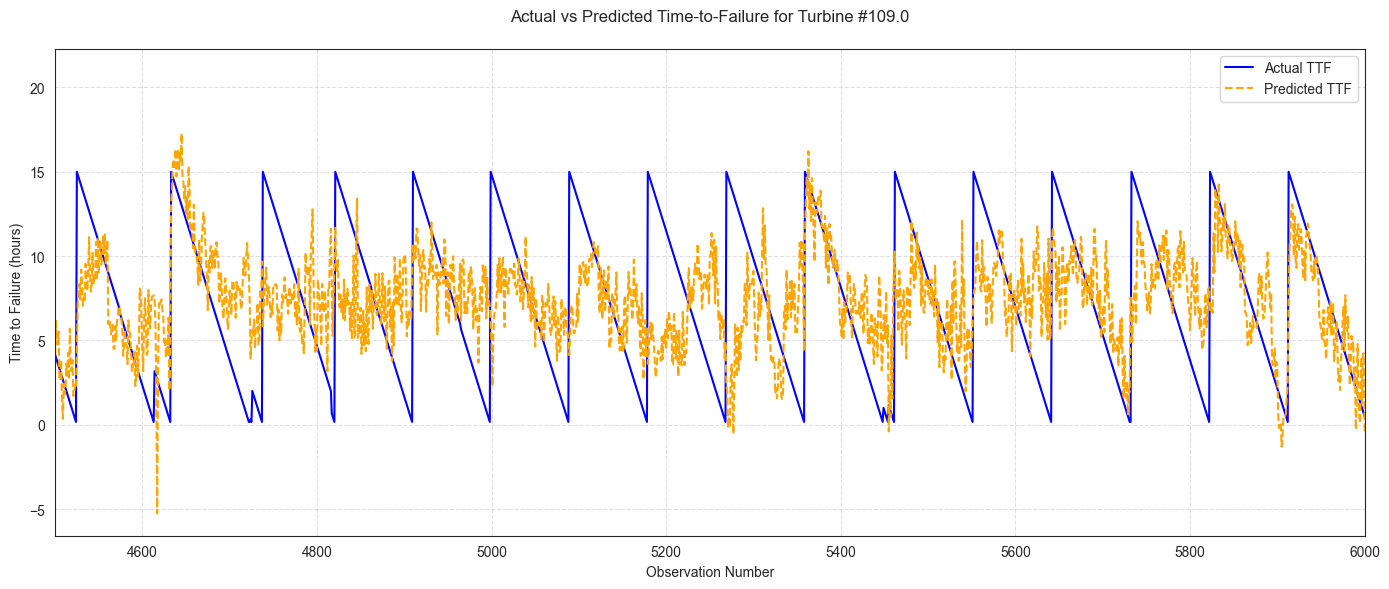

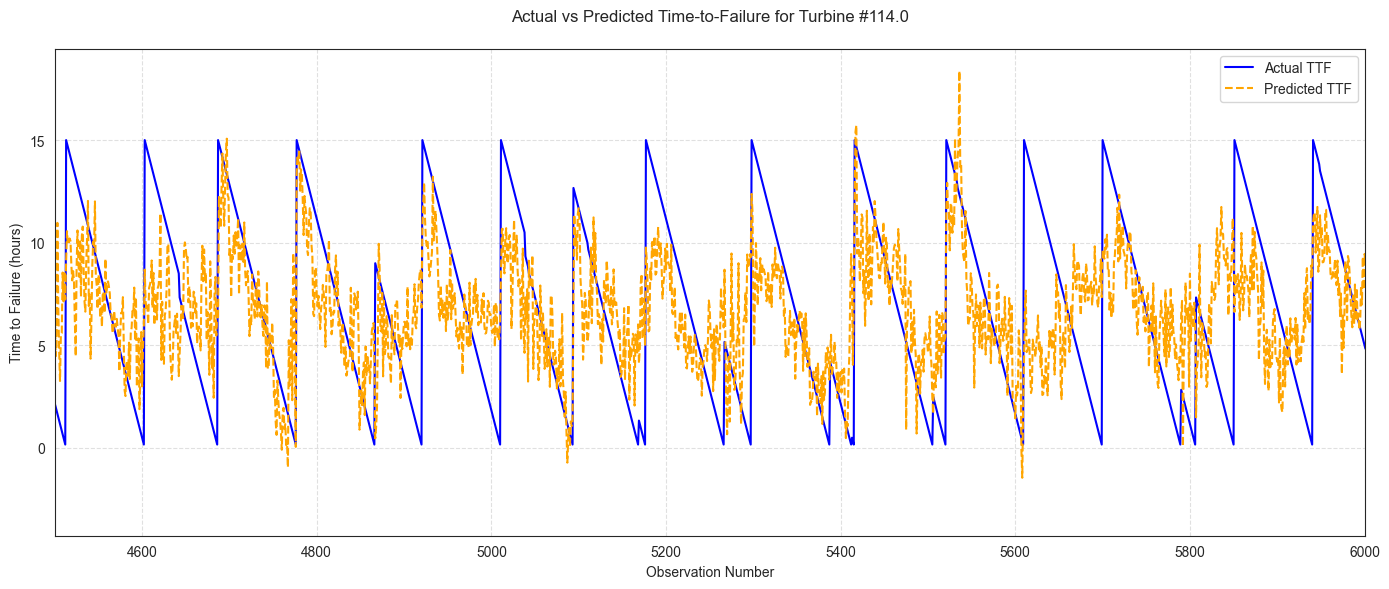

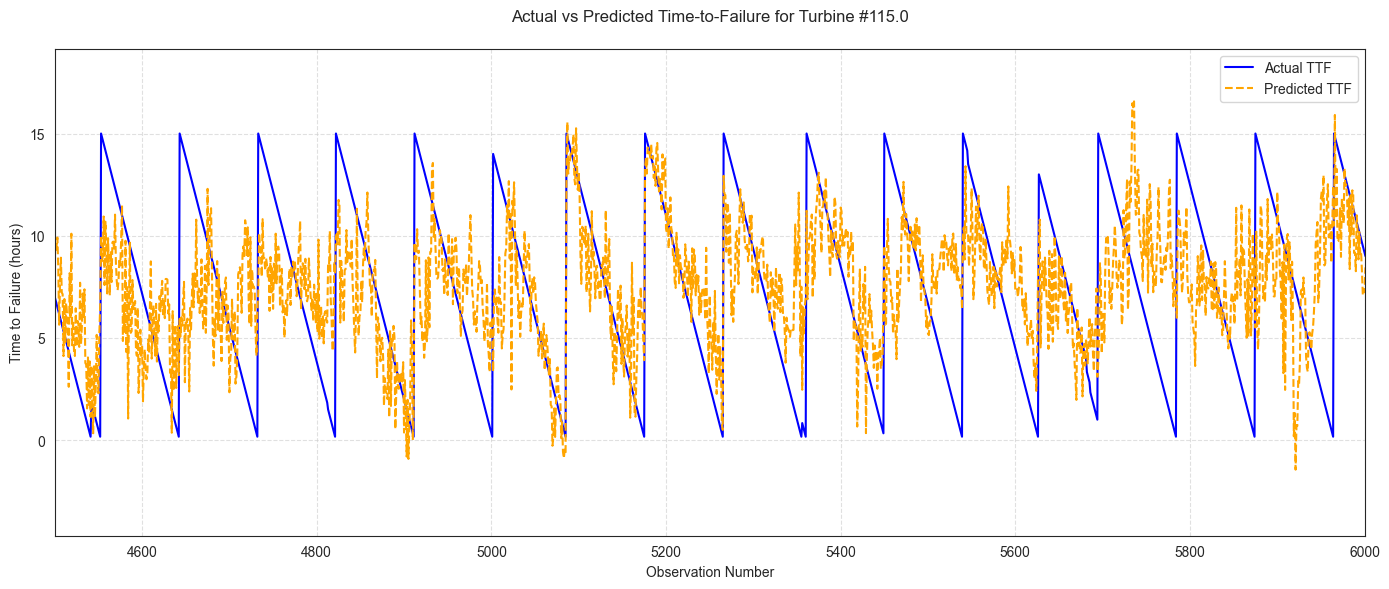

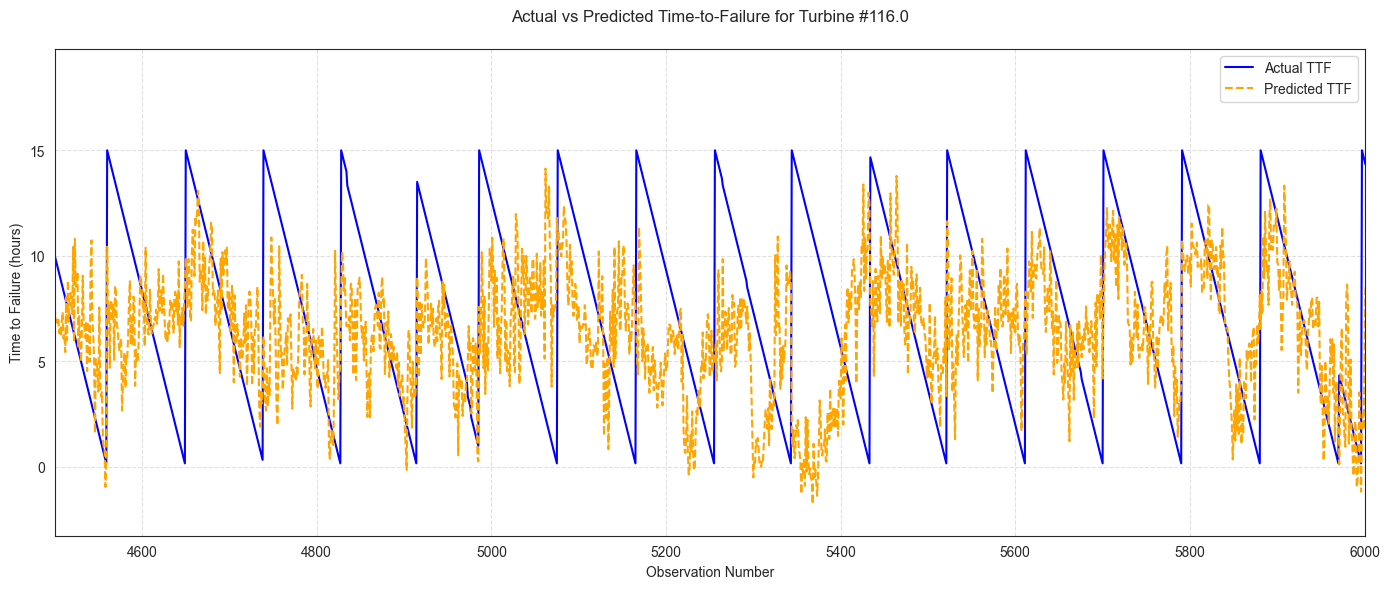

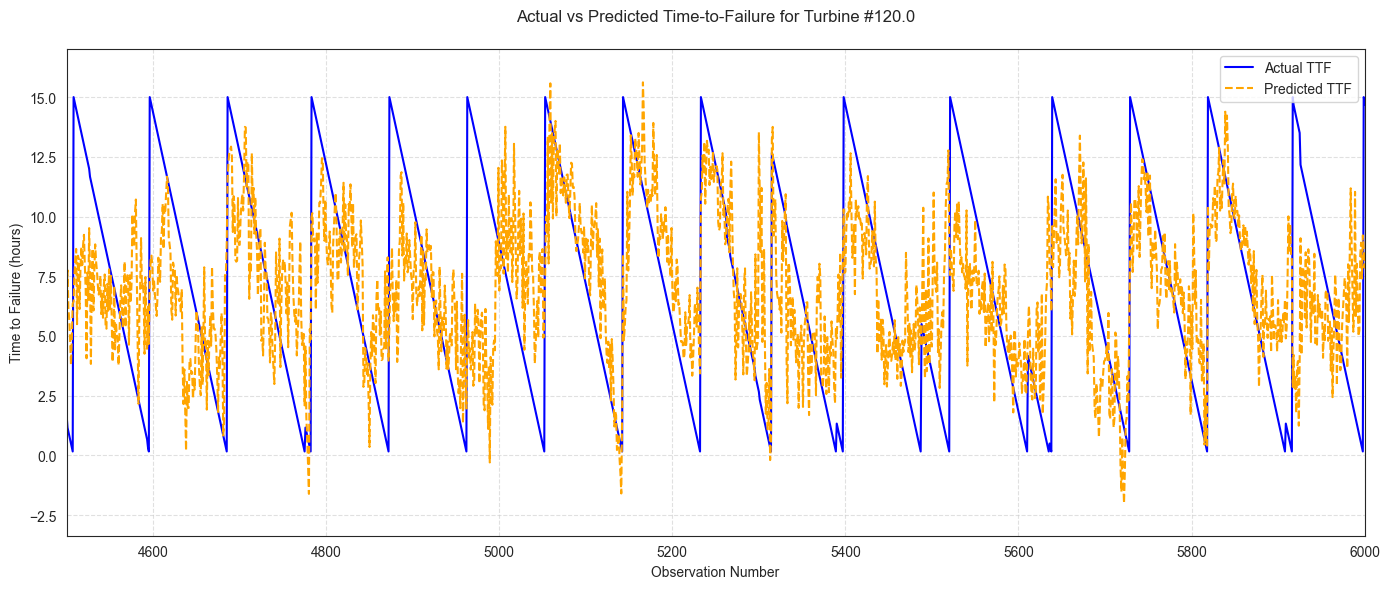

In [40]:
def plot_ttf_comparison(turbine_id, predictions):
    """Plot actual vs predicted TTF for a specific turbine"""
    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))

    plt.figure(figsize=(14, 6))
    plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)
    plt.plot(obs_numbers, data['predicted'], label='Predicted TTF', color='orange', linestyle='--', linewidth=1.5)

    plt.title(f"Actual vs Predicted Time-to-Failure for Turbine #{turbine_id}", pad=20)
    plt.xlabel("Observation Number")
    plt.ylabel("Time to Failure (hours)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    if len(obs_numbers) > 5700:
        plt.xlim(4500, 6000)

    plt.tight_layout()
    plt.savefig(f'figures/ttf_comparison_turbine_{turbine_id}.png', dpi=300)
    plt.show()

# Generate comparison plots for each turbine
print("\nGenerating comparison plots...")
for turbine_id in predictions_A.keys():
    plot_ttf_comparison(turbine_id, predictions_A)

In [41]:
# First train a classifier to get feature importance
X_class = data.drop(['timestamp', 'plant_name', 'errorcode', 'failure'], axis=1)
y_class = data['failure']

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=RANDOM_STATE, stratify=y_class)

# Train classifier
print("\nTraining classifier for feature selection...")
model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train_class[y_train_class==0])/len(y_train_class[y_train_class==1]),
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_estimators=300,
    random_state=RANDOM_STATE
)
model.fit(X_train_class, y_train_class)




Training classifier for feature selection...


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:seasons: object

In [ ]:
# Get feature importance
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

# Select top features
selected_features_B = feature_importance.head(15)['Feature'].tolist()
selected_features_B = [f for f in selected_features_B if f in data_ttf.columns]

print("\nSelected features for Approach B:")
print(selected_features_B)

In [ ]:
# Prepare data for regression
X_B = data_ttf[selected_features_B]
y_B = data_ttf['ttf']
groups_B = data_ttf['plant_name']

# Leave-One-Turbine-Out cross validation
mae_results_B = {}
predictions_B = {}

print("\nTraining regression models for Approach B...")
for train_index, test_index in logo.split(X_B, y_B, groups_B):
    X_train, X_test = X_B.iloc[train_index], X_B.iloc[test_index]
    y_train, y_test = y_B.iloc[train_index], y_B.iloc[test_index]
    turbine_id = groups_B.iloc[test_index[0]]

    # Train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_results_B[turbine_id] = mae

    # Store predictions
    predictions_B[turbine_id] = {
        'actual': y_test.values,
        'predicted': y_pred,
        'timestamps': data_ttf.iloc[test_index]['timestamp'].values
    }

print("\nApproach B MAE Results:")
for turbine_id, mae in sorted(mae_results_B.items()):
    print(f"Turbine {turbine_id}: MAE = {mae:.2f} hours")



In [ ]:
# First train a classifier with SMOTE to get feature importance
print("\nTraining classifier with SMOTE for feature selection...")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_class_smote, y_train_class_smote = smote.fit_resample(X_train_class, y_train_class)

model_smote = xgb.XGBClassifier(
    scale_pos_weight=len(y_train_class_smote[y_train_class_smote==0])/len(y_train_class_smote[y_train_class_smote==1]),
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_estimators=300,
    random_state=RANDOM_STATE
)
model_smote.fit(X_train_class_smote, y_train_class_smote)

# Get feature importance
importance_smote = model_smote.feature_importances_
feature_importance_smote = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': importance_smote
}).sort_values('Importance', ascending=False)
# Select top features
selected_features_C = feature_importance_smote.head(15)['Feature'].tolist()
selected_features_C = [f for f in selected_features_C if f in data_ttf.columns]

print("\nSelected features for Approach C:")
print(selected_features_C)

# Prepare data for regression
X_C = data_ttf[selected_features_C]
y_C = data_ttf['ttf']
groups_C = data_ttf['plant_name']

# Leave-One-Turbine-Out cross validation
mae_results_C = {}
predictions_C = {}

print("\nTraining regression models for Approach C...")
for train_index, test_index in logo.split(X_C, y_C, groups_C):
    X_train, X_test = X_C.iloc[train_index], X_C.iloc[test_index]
    y_train, y_test = y_C.iloc[train_index], y_C.iloc[test_index]
    turbine_id = groups_C.iloc[test_index[0]]

    # Train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_results_C[turbine_id] = mae

    # Store predictions
    predictions_C[turbine_id] = {
        'actual': y_test.values,
        'predicted': y_pred,
        'timestamps': data_ttf.iloc[test_index]['timestamp'].values
    }

print("\nApproach C MAE Results:")
for turbine_id, mae in sorted(mae_results_C.items()):
    print(f"Turbine {turbine_id}: MAE = {mae:.2f} hours")


In [ ]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Turbine': sorted(mae_results_A.keys()),
    'MAE_A': [mae_results_A[t] for t in sorted(mae_results_A.keys())],
    'MAE_B': [mae_results_B[t] for t in sorted(mae_results_B.keys())],
    'MAE_C': [mae_results_C[t] for t in sorted(mae_results_C.keys())]
})